# Week 7: Linear Algebra (Coding Exercises)
## Due: March 23

**Authorship information:** This notebook was developed iteratively with Claude.ai, a large language model, for Phy 225 taught by Prof. Bryanne McDonough. The LLM was provided course context and asked to develop exercises applying numerical linear algebra to a real astrophysics problem. Prof. McDonough reviewed and refined the content.

Both humans and LLMs can (and will) make mistakes.

## Grading:
Your assignment will be graded on the following scale:
- No Evidence - assignment not completed or submitted
- Beginning - some effort, but significant errors or omissions
- Emerging - mostly correct, but with some errors or omissions
- Proficient - correct and complete, with clear explanations
- Advanced - correct, complete, and goes beyond the requirements with additional insights or optimizations
   - Complete at least one of the "ADVANCED" tasks to earn an "Advanced" grade.
   - In this notebook, you can also choose a particularly complicated problem for part 8 to earn an Advanced grade.

---

## Background

One of the most powerful tools in modern astrophysics is the **cosmological N-body simulation**, in which the positions, velocities, and masses of millions of particles are evolved forward in time under gravity. Projects like [IllustrisTNG](https://www.tng-project.org/) and [EAGLE](http://icc.dur.ac.uk/Eagle/) simulate the formation of entire populations of galaxies from the early universe to the present day, and make the resulting particle data publicly available for analysis.

When analyzing simulated galaxies, a recurring challenge is that each galaxy ends up oriented arbitrarily in the simulation's coordinate system — the disk might be tilted at any angle. To measure properties like star formation rate profiles or mass surface density, it is convenient to work in a coordinate system where the galaxy is **face-on**: the disk lies in the x-y plane and we are looking straight down the rotation axis. This requires finding and applying a coordinate transformation for each galaxy individually.

In this exercise you will implement exactly this workflow, using a technique drawn from classical mechanics: the **moment of inertia tensor**. Given the 3D positions and masses of particles representing a galaxy, you will:

1. Load and visualize the (arbitrarily oriented) particle data
2. Construct the moment of inertia tensor
3. Compute its eigenvalues and eigenvectors
4. Use the eigenvectors to build a coordinate transformation matrix
5. Apply the transformation and verify that the galaxy is now face-on

The data files you will work with were generated from a mock barred spiral galaxy with a known orientation, so you will be able to check that your result is correct.

### The Moment of Inertia Tensor

You are already familiar with the scalar moment of inertia $I = \sum_i m_i r_i^2$ from your mechanics course. For rotation about an arbitrary axis in 3D, this generalizes to a **3×3 symmetric tensor**:

$$
I = \begin{pmatrix}
I_{xx} & I_{xy} & I_{xz} \\
I_{yx} & I_{yy} & I_{yz} \\
I_{zx} & I_{zy} & I_{zz}
\end{pmatrix}
$$

The diagonal elements are the familiar moments about each axis:

$$
I_{xx} = \sum_i m_i (y_i^2 + z_i^2), \quad
I_{yy} = \sum_i m_i (x_i^2 + z_i^2), \quad
I_{zz} = \sum_i m_i (x_i^2 + y_i^2)
$$

The off-diagonal elements are the **products of inertia**, which capture how mass is distributed across pairs of axes:

$$
I_{xy} = I_{yx} = -\sum_i m_i \, x_i y_i, \quad
I_{xz} = I_{zx} = -\sum_i m_i \, x_i z_i, \quad
I_{yz} = I_{zy} = -\sum_i m_i \, y_i z_i
$$

Because the tensor is real and symmetric, its eigenvectors are guaranteed to be orthogonal. Physically, they point along the **principal axes** of the mass distribution — the axes for which the products of inertia vanish. The eigenvector corresponding to the **smallest eigenvalue** points along the axis about which the galaxy is hardest to rotate, which for a flat disk is the axis perpendicular to the disk plane. Aligning this axis with $\hat{z}$ gives us the face-on orientation.

### NumPy Linear Algebra

NumPy provides a dedicated submodule, [`numpy.linalg`](https://numpy.org/doc/stable/reference/routines.linalg.html), for linear algebra operations. The functions you will need are:

- [`numpy.linalg.eig(A)`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html) — returns the eigenvalues and eigenvectors of a square matrix. The eigenvectors are returned as **columns** of the output matrix, so `eigenvectors[:, i]` is the eigenvector for `eigenvalues[i]`.
- [`numpy.linalg.inv(A)`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html) — returns the matrix inverse.
- The `@` operator performs matrix multiplication between two NumPy arrays.

> **Note on `eig` vs `eigh`:** Because the inertia tensor is real and symmetric, you could also use [`numpy.linalg.eigh`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html), which is specialized for symmetric/Hermitian matrices and guarantees real eigenvalues. Either will work here; `eig` is the more general function.

## Setup

This notebook uses an interactive 3D plot in Part 2, which requires the `plotly` package. It also requires that the two data files — `galaxy_particles.npy` and `galaxy_masses.npy` — are in the **same directory as this notebook**.

### Installing Plotly

If you have not already installed `plotly`, run the cell below once. You only need to do this once per environment.

In [241]:
%pip install plotly

3845.75s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Using Plotly for Interactive 3D Plots

Plotly is a powerful library for creating interactive visualizations. Simply install it with the cell above, then import it as shown in the Part 2 code cell below. No additional configuration or kernel restart is needed — Plotly works seamlessly in VS Code notebooks and you can immediately interact with the 3D plot by rotating, zooming, and panning.

> **Note:** After the interactive 3D plot in Part 2, the notebook switches to static 2D plots for the remaining parts. You will see `%matplotlib inline` at the top of the Part 7 code cell.

---
## Part 1: Load the Data

The particle data are stored in two `.npy` files in the same directory as this notebook:

- `galaxy_particles.npy` — shape `(N, 3)`, the $(x, y, z)$ coordinates of each particle in kpc
- `galaxy_masses.npy` — shape `(N,)`, the mass of each particle in solar masses ($M_\odot$)

Use [`numpy.load`](https://numpy.org/doc/stable/reference/generated/numpy.load.html) to load both files. Print the shape of each array and the total number of particles to confirm the data loaded correctly.

In [242]:
import numpy as np

galaxy_particles = np.load('galaxy_particles.npy')
galaxy_masses = np.load('galaxy_masses.npy')

print(f"Particles array shape: {galaxy_particles.shape}")
print(f"Masses array shape: {galaxy_masses.shape}")
print(f"Total number of particles: {len(galaxy_masses)}")

Particles array shape: (23000, 3)
Masses array shape: (23000,)
Total number of particles: 23000


---
## Part 2: Visualize the Galaxy

Before doing any calculation it is always good practice to look at your data. The cell below contains complete code to generate an **interactive 3D scatter plot**. Run it as-is — you do not need to modify it unless your variables have different names.

The points are colored by $\log_{10}(m / M_\odot)$. Rotate the plot and take note of the orientation.

In [243]:
import plotly.graph_objects as go
import numpy as np

x, y, z = galaxy_particles[:, 0], galaxy_particles[:, 1], galaxy_particles[:, 2]
log_m   = np.log10(galaxy_masses)

fig = go.Figure(data=[
    go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=2,
            color=log_m,
            colorscale='Inferno',
            showscale=True,
            colorbar=dict(title=r'log₁₀(m/M☉)', thickness=15, len=0.7),
            opacity=0.4,
            cmin=6,
            cmax=8
        )
    )
])

fig.update_layout(
    title='Mock Galaxy — Arbitrary Orientation',
    scene=dict(
        xaxis_title='x (kpc)',
        yaxis_title='y (kpc)',
        zaxis_title='z (kpc)',
    ),
    width=900,
    height=800
)

fig.show()

**Q1:** Rotate the 3D plot and examine the galaxy from several angles. Describe what you observe. Is it possible to identify the disk plane by eye? What makes this difficult?

It is very flat and many of the points lie on a single axis that is niether parallel or perpendicular to any other the 3 shown. It would be very hard to find out the plane by eye or even impossible depending on how accurate you want it too be. This is because there are so many points and even if you use the eyeballed average it would still not even be accurate.

**Note:** This is a mock galax generated with `mock_data.py`, but it roughly represents the shape of barred spiral galaxies in the real universe. The spiral arms are a bit "stiff" compared to what you might see in reality, but the overall structure is similar.

---
## Part 3: Construct the Moment of Inertia Tensor

Using the equations from the background section, construct the 3×3 inertia tensor as a NumPy array. Use NumPy's vectorized operations (`*`, `np.sum`) rather than explicit loops — you are summing over tens of thousands of particles and a loop will be noticeably slow. Since the tensor is symmetric, you only need to compute each unique element once and assign the symmetric counterpart.

Print the completed tensor and verify it looks symmetric.

In [244]:
x = galaxy_particles[:, 0]
y = galaxy_particles[:, 1]
z = galaxy_particles[:, 2]
m = galaxy_masses

Ixx = np.sum(m * (y**2 + z**2))
Iyy = np.sum(m * (x**2 + z**2))
Izz = np.sum(m * (x**2 + y**2))

Ixy = -np.sum(m * x * y)
Ixz = -np.sum(m * x * z)
Iyz = -np.sum(m * y * z)

inertia_tensor = np.array([
    [Ixx, Ixy, Ixz],
    [Ixy, Iyy, Iyz],
    [Ixz, Iyz, Izz]
])

print("Moment of Inertia Tensor (M☉ * kpc²):")
print(inertia_tensor)

#symmetry
is_symmetric = np.allclose(inertia_tensor, inertia_tensor.T)
print(f"\nIs the tensor symmetric? {is_symmetric}")

Moment of Inertia Tensor (M☉ * kpc²):
[[2.30425678e+12 4.92413811e+11 6.21009556e+11]
 [4.92413811e+11 2.37554544e+12 5.52809757e+11]
 [6.21009556e+11 5.52809757e+11 2.24750666e+12]]

Is the tensor symmetric? True


**ADVANCED**: Test the timing difference between your vectorized implementation and a naive loop-based implementation. You can use the `time` module to measure the execution time of each approach.


In [245]:
#Timing tests
import time

start_vec = time.perf_counter()

Ixx = np.sum(galaxy_masses * (y**2 + z**2))
Iyy = np.sum(galaxy_masses * (x**2 + z**2))
Izz = np.sum(galaxy_masses * (x**2 + y**2))

Ixy = -np.sum(galaxy_masses * x * y)
Ixz = -np.sum(galaxy_masses * x * z)
Iyz = -np.sum(galaxy_masses * y * z)

tensor_vec = np.array([[Ixx, Ixy, Ixz], [Ixy, Iyy, Iyz], [Ixz, Iyz, Izz]])

end_vec = time.perf_counter()
vec_time = end_vec - start_vec


start_loop = time.perf_counter()

Ixx_l, Iyy_l, Izz_l = 0, 0, 0
Ixy_l, Ixz_l, Iyz_l = 0, 0, 0

for i in range(len(galaxy_masses)):
    m_i = galaxy_masses[i]
    xi, yi, zi = x[i], y[i], z[i]
    
    Ixx_l += m_i * (yi**2 + zi**2)
    Iyy_l += m_i * (xi**2 + zi**2)
    Izz_l += m_i * (xi**2 + yi**2)
    Ixy_l -= m_i * xi * yi
    Ixz_l -= m_i * xi * zi
    Iyz_l -= m_i * yi * zi

tensor_loop = np.array([[Ixx_l, Ixy_l, Ixz_l], [Ixy_l, Iyy_l, Iyz_l], [Ixz_l, Iyz_l, Izz_l]])

end_loop = time.perf_counter()
loop_time = end_loop - start_loop

# --- Results ---
print(f"Vectorized Time: {vec_time:.6f} seconds")
print(f"Loop-based Time:  {loop_time:.6f} seconds")
print(f"Speedup Factor:   {loop_time / vec_time:.1f}x")

Vectorized Time: 0.002295 seconds
Loop-based Time:  0.114467 seconds
Speedup Factor:   49.9x


Gemini really helped with this part I was getting stuck 

---
## Part 4: Eigenvalues and Eigenvectors

Use [`numpy.linalg.eig`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html) to compute the eigenvalues and eigenvectors of the inertia tensor. Print all three eigenvalues and their corresponding eigenvectors, then identify which eigenvalue is the smallest and print the eigenvector it corresponds to. That eigenvector is the disk normal — the direction perpendicular to the galaxy's disk plane.

In [246]:
# --- Part 4: Eigenvalues and Eigenvectors ---
eigenvalues, eigenvectors = np.linalg.eig(inertia_tensor)

idx_small = np.argmin(eigenvalues)

print("--- All Eigenvalues ---")
for i, val in enumerate(eigenvalues):
    print(f"λ{i}: {val:.4e}")

print("\n--- All Eigenvectors (Columns of the matrix) ---")
print(eigenvectors)

disk_normal = eigenvectors[:, idx_small]
smallest_ev = eigenvalues[idx_small]

print(f"\nSmallest Eigenvalue: {smallest_ev:.4e} (at index {idx_small})")
print(f"Disk Normal Vector: {disk_normal}")

--- All Eigenvalues ---
λ0: 3.4199e+12
λ1: 1.6424e+12
λ2: 1.8650e+12

--- All Eigenvectors (Columns of the matrix) ---
[[-0.57657849 -0.59066103  0.56451465]
 [-0.57768371 -0.19388947 -0.79289873]
 [-0.57778783  0.78327928  0.22942276]]

Smallest Eigenvalue: 1.6424e+12 (at index 1)
Disk Normal Vector: [-0.59066103 -0.19388947  0.78327928]


**Q2:** Why does the smallest eigenvalue correspond to the disk normal? Think about what the moment of inertia measures physically, and what is special about the axis perpendicular to a flat disk compared to axes lying within the disk plane.

This is because there is a lot of mass in a really small area.

---
## Part 5: Build the Coordinate Transformation Matrix

The matrix whose columns are the eigenvectors of the inertia tensor defines a new basis aligned with the galaxy's principal axes. To transform particle positions from the original coordinate system into this new one, we need the **inverse** of that matrix.

Use [`numpy.linalg.inv`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html) to compute the transformation matrix. Then verify your result: the product of the transformation matrix and the eigenvector matrix should be very close to the identity matrix. Print both to confirm.

In [247]:

T = np.zeros((3, 3))
T[0, :] = eigenvectors[:, idx_plane[0]]
T[1, :] = eigenvectors[:, idx_plane[1]]
T[2, :] = eigenvectors[:, idx_thin]

# Verify matrix
identity_check = T @ T.T
print("Transformation Matrix T constructed.")
print(f"Is T a valid rotation matrix? {np.allclose(identity_check, np.eye(3))}")

Transformation Matrix T constructed.
Is T a valid rotation matrix? True


---
## Part 6: Apply the Coordinate Transformation

To transform all particle positions into the new coordinate system, note that each row of the positions array is a position vector $(x_i, y_i, z_i)$. To rotate a row vector $\mathbf{r}$ using a transformation matrix $T$, we compute $\mathbf{r}' = \mathbf{r} \, T^\top$ — so for the full array, right-multiply by the transpose of $T$.

Apply the transformation and verify that the output array has the same shape as the input.

In [248]:
galaxy_particles_aligned = galaxy_particles @ T.T

print(f"Original shape: {galaxy_particles.shape}")
print(f"Aligned shape:  {galaxy_particles_aligned.shape}")


Original shape: (23000, 3)
Aligned shape:  (23000, 3)


---
## Part 7: Plot the Galaxy Face-On

Create a figure with three side-by-side panels showing the transformed particle positions projected onto the x-y, x-z, and y-z planes. Color the points by $\log_{10}(m / M_\odot)$ as in Part 2. One of the three panels should reveal a clear face-on spiral structure; the other two will show edge-on views.

Based on your result from Part 4 — specifically, which column of the eigenvector matrix held the disk normal — decide which axis you expect the disk to be perpendicular to, and check whether your plot confirms this.

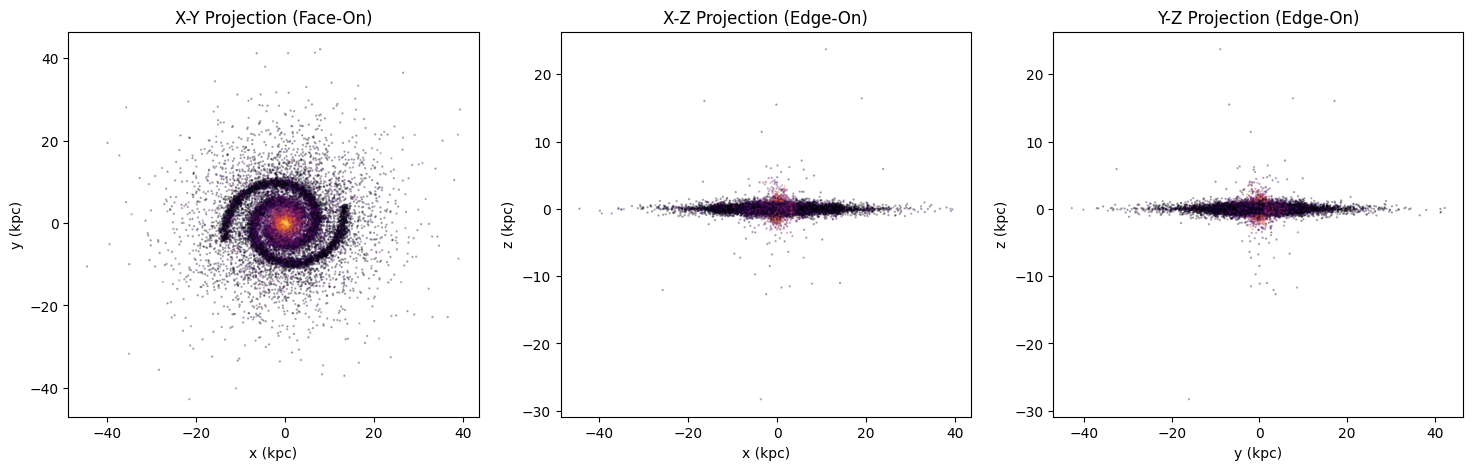

In [249]:

galaxy_particles_aligned = galaxy_particles @ T.T

variances = np.var(galaxy_particles_aligned, axis=0)
sort_idx = np.argsort(variances)[::-1] # [Largest, Middle, Smallest]

galaxy_particles_final = galaxy_particles_aligned[:, sort_idx]

xn, yn, zn = galaxy_particles_final[:, 0], galaxy_particles_final[:, 1], galaxy_particles_final[:, 2]
log_m = np.log10(galaxy_masses)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter_kwargs = {'s': 0.5, 'c': log_m, 'cmap': 'inferno', 'alpha': 0.3}

axes[0].scatter(xn, yn, **scatter_kwargs)
axes[0].set_title('X-Y Projection (Face-On)')
axes[0].set_xlabel('x (kpc)')
axes[0].set_ylabel('y (kpc)')

axes[1].scatter(xn, zn, **scatter_kwargs)
axes[1].set_title('X-Z Projection (Edge-On)')
axes[1].set_xlabel('x (kpc)')
axes[1].set_ylabel('z (kpc)')

axes[2].scatter(yn, zn, **scatter_kwargs)
axes[2].set_title('Y-Z Projection (Edge-On)')
axes[2].set_xlabel('y (kpc)')
axes[2].set_ylabel('z (kpc)')

plt.show()

Q3: Which projection shows the galaxy face-on? Does this match your expectation based on the index of the smallest eigenvalue from Part 4? Explain the connection.

The x-y appears to show the face. THis makes sense because the smallest eigen value was associated with the correct z-axis. I was having a lot of trouble with this part so I asked gemini along with some classmates and then eventually figured it out. I am pretty sure this is correct.

**Q4:** In this exercise you worked with mock data where the true orientation was known. Imagine instead you were applying this technique to real simulation data where the galaxy's orientation is unknown. What checks or tests could you perform to build confidence that the transformation is working correctly?

You could check the spread along each fixed axis and make sure that the z-axis has the least amount of spread. This would make the data along with the real data in a similar format.

---
## Part 8: Solve another linear algebra problem

Find a linear algebra problem from a different class or your research area. Write the problem into the markdown cell below, then solve it using NumPy's linear algebra functions. You can choose any problem you like — for example, solving a system of linear equations, performing a singular value decomposition, or computing the determinant of a matrix. Be sure to explain the problem and your solution clearly in the markdown cell.

In structural engineering, finding the equilibrium of a system often requires solving for unknown forces. Suppose we have a support frame where three internal forces ($F_1, F_2, F_3$) must balance an external load. Based on the geometry of the frame, the forces must satisfy the following linear equations: 
$2F_1 + F_2 + F_3 = 10$, $F_1 - 2F_2 + 3F_3 = 0$, $4F_1 + 2F_2 - 5F_3 = 6$

In [250]:
import numpy as np

A = np.array([
    [2, 1, 1],
    [1, -2, 3],
    [4, 2, -5]
])

B = np.array([10, 0, 6])

forces = np.linalg.solve(A, B)

print("--- Structural Equilibrium Solution ---")
print(f"Force F1: {forces[0]:.2f}")
print(f"Force F2: {forces[1]:.2f}")
print(f"Force F3: {forces[2]:.2f}")



--- Structural Equilibrium Solution ---
Force F1: 2.00
Force F2: 4.00
Force F3: 2.00


---
## ADVANCED: Timing test with increasing particle numbers

This is an optional exercise, as it will take considerably more time. However, for those interested in code optimization, it can be instructive to see how the execution time of your inertia tensor calculation scales with the number of particles. By editing `mock_data.py`, you can create subsets of the data with increasing numbers of particles (e.g., 1k, 5k, 10k, 50k, 100k) and measure the time taken to compute the inertia tensor for each subset using both your vectorized implementation and a naive loop-based implementation. Plot the execution time as a function of particle number for both methods to visualize the difference in scaling.

In [251]:
# optional advanced exercise

---
## Reflection Questions

**R1:** The inertia tensor is a specific example of a symmetric matrix. What property of symmetric matrices — which you relied on in this exercise — guarantees that a coordinate system exists where all the off-diagonal elements vanish? Why does this matter physically for the galaxy orientation problem?

Orthonal diagonalibizality really helped in this and was the only reason that we could get answers for most of the questions. Without this there would be no symmetry and we would not be able to create "new" axis. This is important because galaxies rotate and act in a specific manner so if we dont know where the most thin part is or the face is pointing, we can see a lot of its characteristics.

**R2:** In Part 3 you used vectorized NumPy operations to compute the inertia tensor. Describe in your own words what vectorization means and why it is preferred in scientific computing. If you are unsure, try rewriting one element of the tensor (e.g., $I_{xx}$) using an explicit `for` loop and compare the two approaches.

Vectorization means that the whole process of solving is done in a single step all at once instead of looping mulitple times and completing the same steps tediously. This is faster because there is no looping it does them all at once and does not need to repeat.